In [2]:
import json

def load_result_file(filepath):
    """Load and validate a result JSON file."""
    with open(filepath, "r") as f:
        try:
            data = json.load(f)
        except Exception as e:
            raise ValueError(f"Failed to parse JSON: {e}")

    # Basic structural validation
    if not isinstance(data, list):
        raise ValueError("Expected list of records")

    required_keys = {
        "concurrency", "avg_exec_time", "avg_entry_total_time",
        "offload_count", "avg_cpu_usage", "avg_mem_usage_MB"
    }

    for i, entry in enumerate(data):
        if not isinstance(entry, dict):
            raise ValueError(f"Item {i} is not a dict")
        missing = required_keys - entry.keys()
        if missing:
            raise ValueError(f"Missing keys in item {i}: {missing}")

    return data


In [3]:
file_path = "tmp data/results_basic_federated.json"
results_basic_federated = load_result_file(file_path)

# 预览前几项
results_basic_federated[:3]

[{'fn_type': 'basic',
  'concurrency': 1,
  'avg_exec_time': 0.04898733615875244,
  'max_exec_time': 0.09939217567443848,
  'min_exec_time': 0.04558110237121582,
  'avg_entry_total_time': 0.6076272349999999,
  'max_entry_time': 0.745728,
  'min_entry_time': 0.524622,
  'offload_count': 0,
  'total_offload_count': 0,
  'avg_cpu_usage': 98.85112750515127,
  'avg_mem_usage_MB': 1027.3533854166667,
  'total_cpu_usage': 593.1067650309076,
  'total_mem_usage_MB': 6164.1203125,
  'samples': 200},
 {'fn_type': 'basic',
  'concurrency': 2,
  'avg_exec_time': 0.06134386360645294,
  'max_exec_time': 0.13491034507751465,
  'min_exec_time': 0.04532432556152344,
  'avg_entry_total_time': 0.6243510225000004,
  'max_entry_time': 0.824516,
  'min_entry_time': 0.492887,
  'offload_count': 0,
  'total_offload_count': 0,
  'avg_cpu_usage': 109.11420813582286,
  'avg_mem_usage_MB': 1034.4596354166665,
  'total_cpu_usage': 654.6852488149372,
  'total_mem_usage_MB': 6206.757812499999,
  'samples': 400},
 {'f

In [4]:
import os

# 你可以根据实际路径调整文件名
file_paths = {
    "basic_centralized": "tmp data/results_basic_centralized.json",
    "basic_decentralized": "tmp data/results_basic_decentralized.json",
    "basic_federated": "tmp data/results_basic_federated.json",
    "data_local_centralized": "tmp data/results_data_local_centralized.json",
    "data_local_decentralized": "tmp data/results_data_local_decentralized.json",
    "data_local_federated": "tmp data/results_data_local_federated.json",
}

# 批量加载
loaded_data = {}
for key, path in file_paths.items():
    try:
        loaded_data[key] = load_result_file(path)
    except Exception as e:
        print(f"[ERROR] Failed to load {key}: {e}")


In [6]:
def extract_plot_data(dataset):
    return {
        "concurrency": [entry["concurrency"] for entry in dataset],
        "avg_exec_time": [entry["avg_exec_time"] for entry in dataset],
        "avg_entry_time": [entry["avg_entry_total_time"] for entry in dataset],
        "offload_count": [entry["offload_count"] for entry in dataset],
        "cpu": [entry["avg_cpu_usage"] for entry in dataset],
        "mem": [entry["avg_mem_usage_MB"] for entry in dataset],
    }

plot_data = {k: extract_plot_data(v) for k, v in loaded_data.items()}


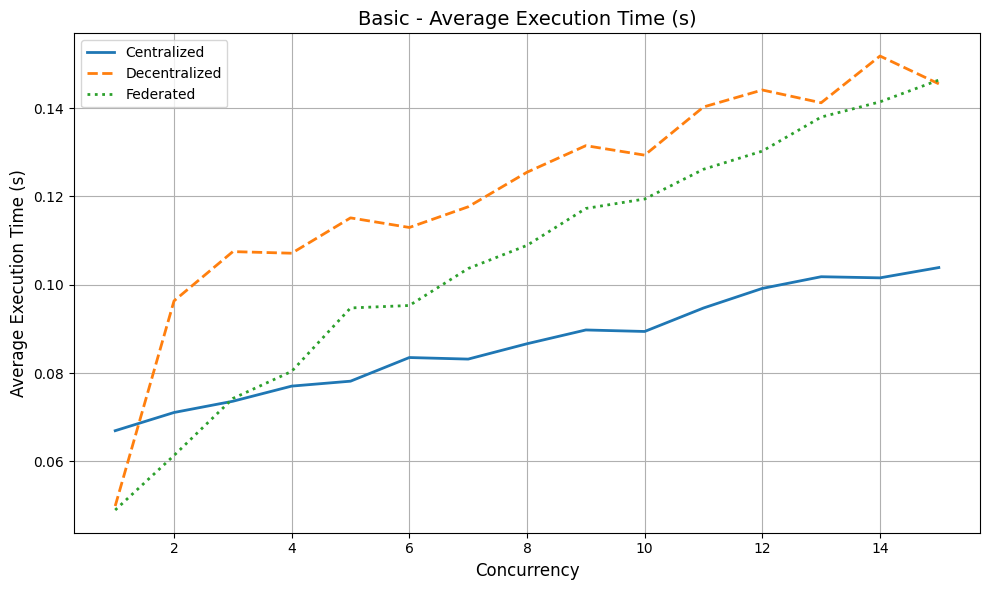

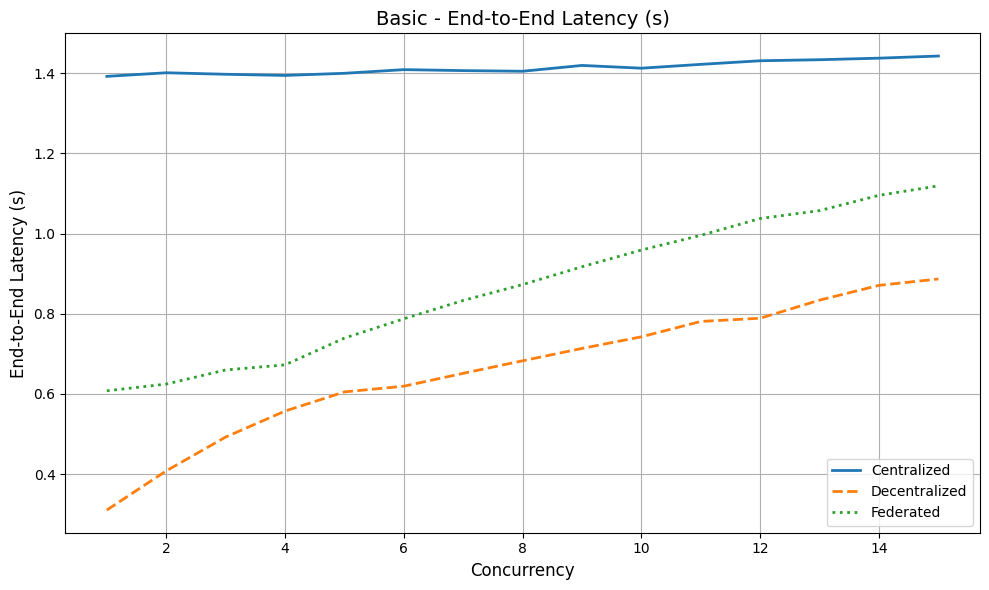

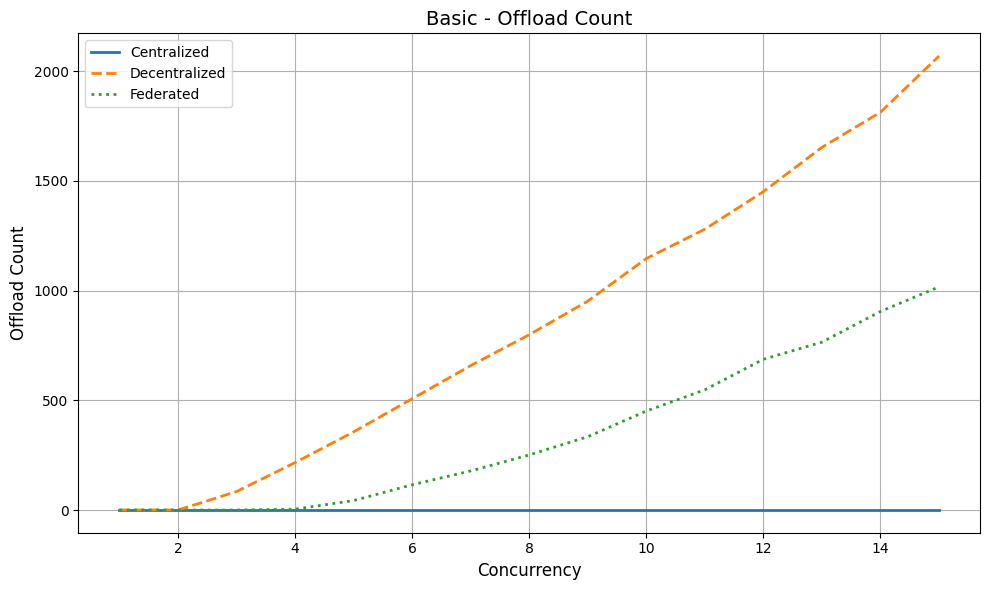

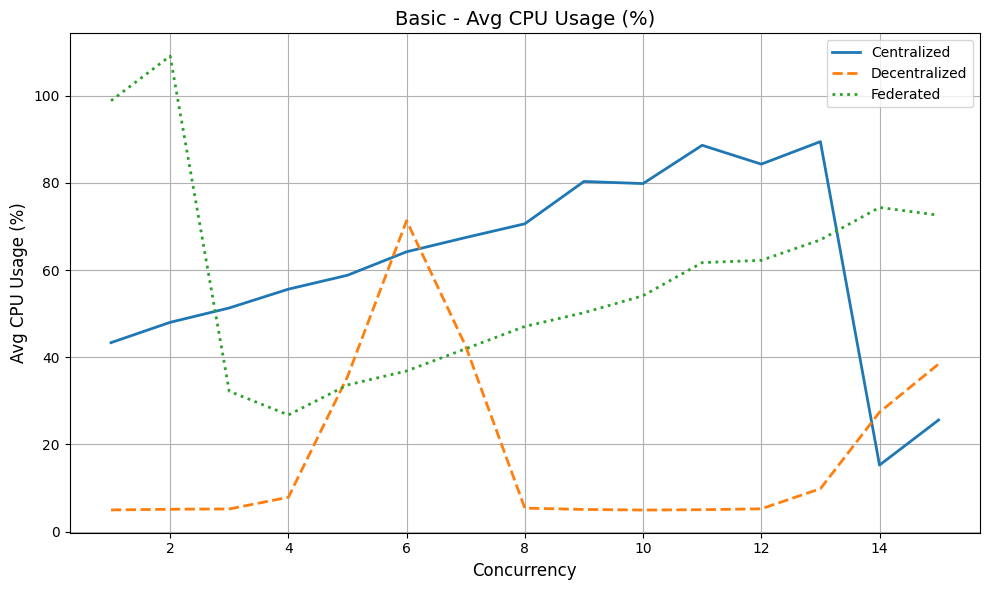

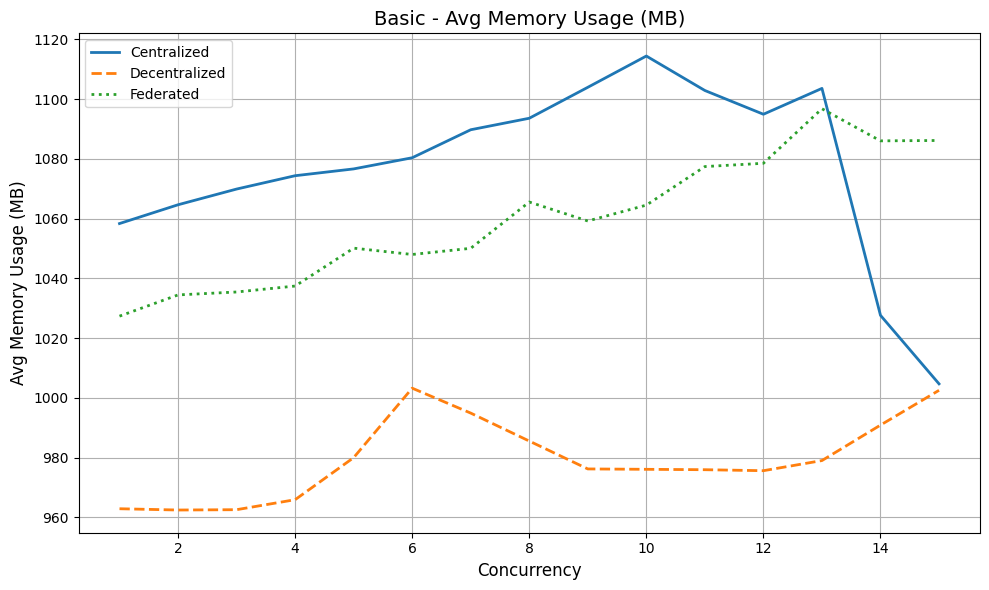

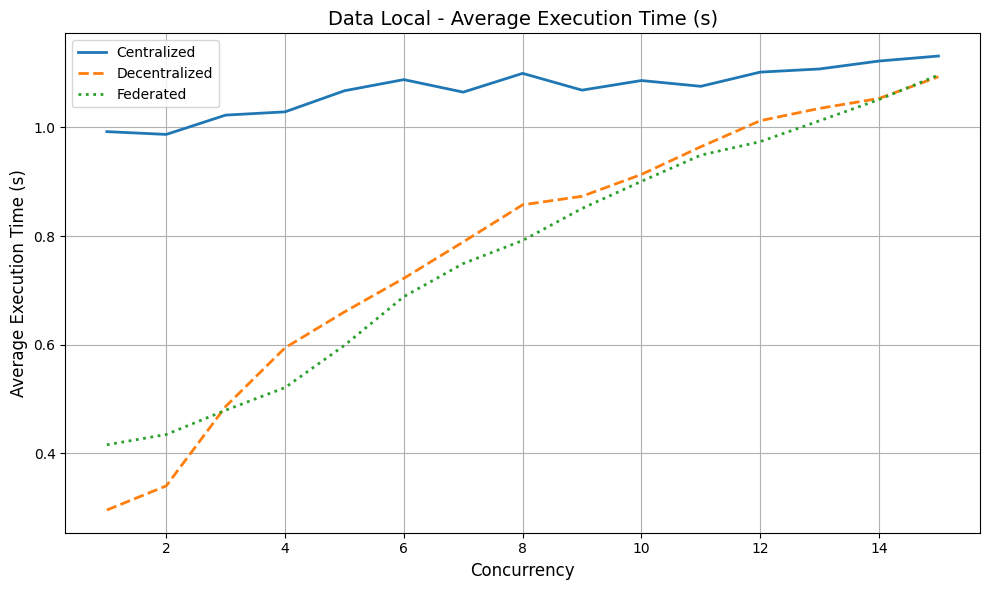

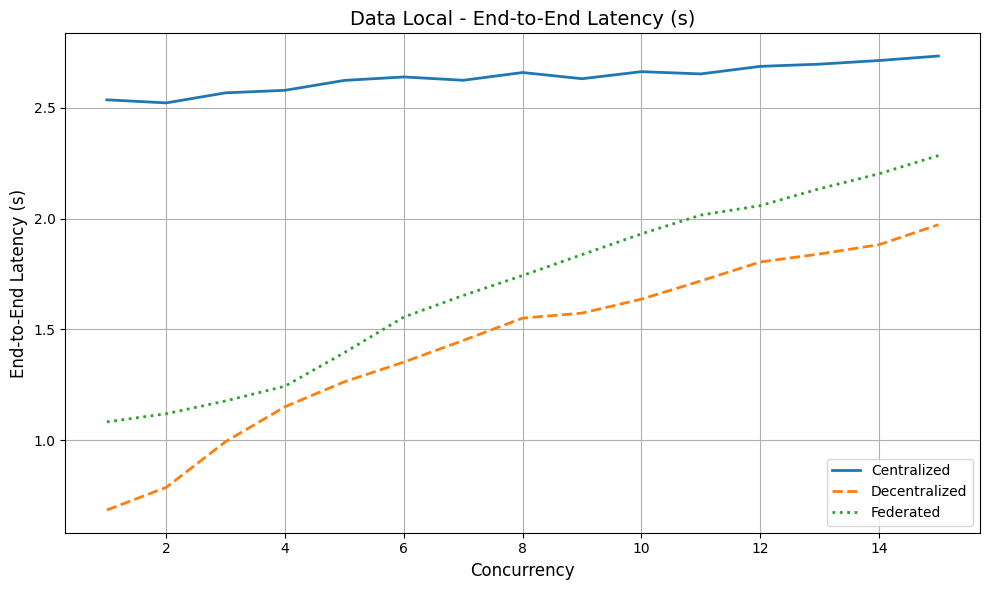

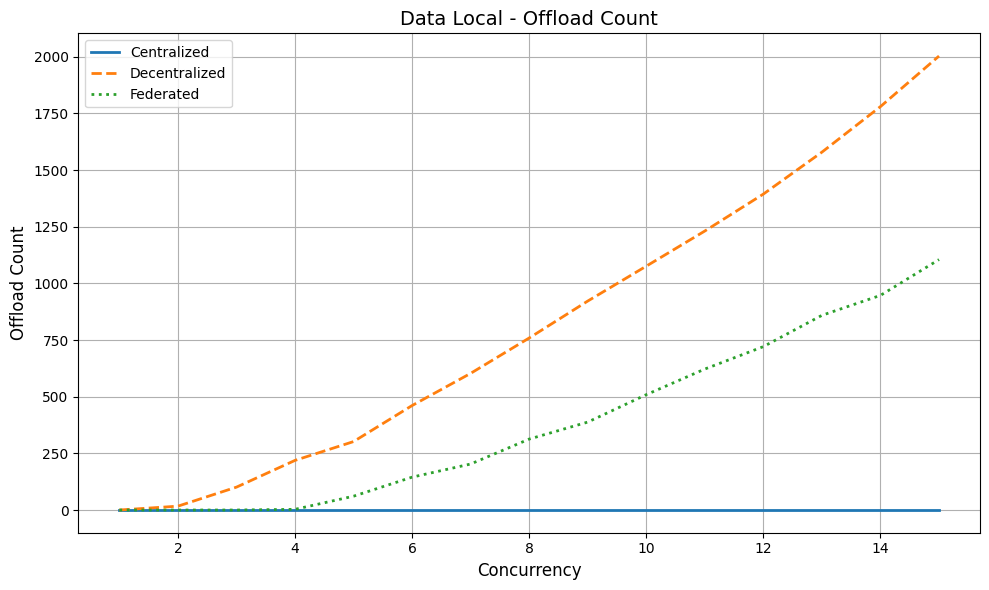

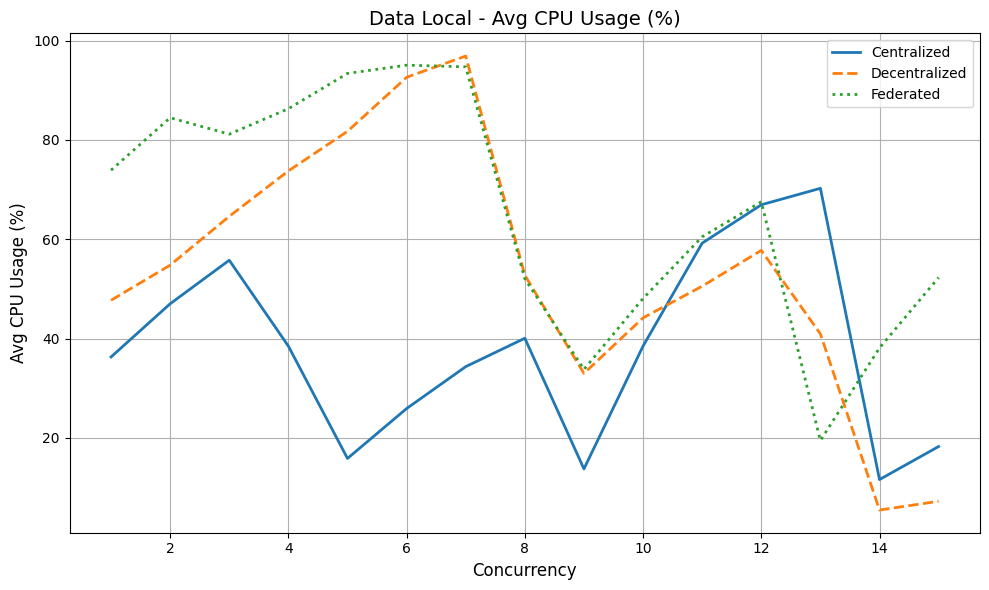

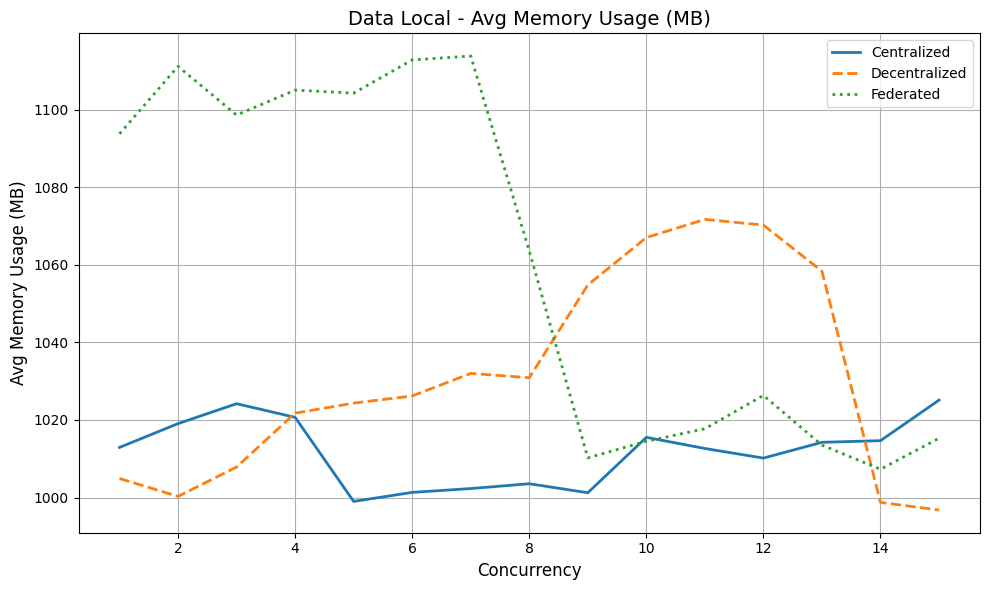

In [8]:
import matplotlib.pyplot as plt

def plot_single_metric(task_type, metric_key, metric_label, plot_data):
    """绘制单个指标图（一个任务类型 + 多种架构）"""
    plt.figure(figsize=(10, 6))
    line_style = {
        "centralized": "solid",
        "decentralized": "dashed",
        "federated": "dotted"
    }

    for arch in ["centralized", "decentralized", "federated"]:
        key = f"{task_type}_{arch}"
        if key in plot_data:
            plt.plot(
                plot_data[key]["concurrency"],
                plot_data[key][metric_key],
                label=arch.title(),
                linestyle=line_style[arch],
                linewidth=2
            )

    plt.title(f"{task_type.replace('_', ' ').title()} - {metric_label}", fontsize=14)
    plt.xlabel("Concurrency", fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 所有指标
metrics_info = {
    "avg_exec_time": "Average Execution Time (s)",
    "avg_entry_time": "End-to-End Latency (s)",
    "offload_count": "Offload Count",
    "cpu": "Avg CPU Usage (%)",
    "mem": "Avg Memory Usage (MB)"
}

# Basic task 单独图
for metric, label in metrics_info.items():
    plot_single_metric("basic", metric, label, plot_data)

# Data-local task 单独图
for metric, label in metrics_info.items():
    plot_single_metric("data_local", metric, label, plot_data)



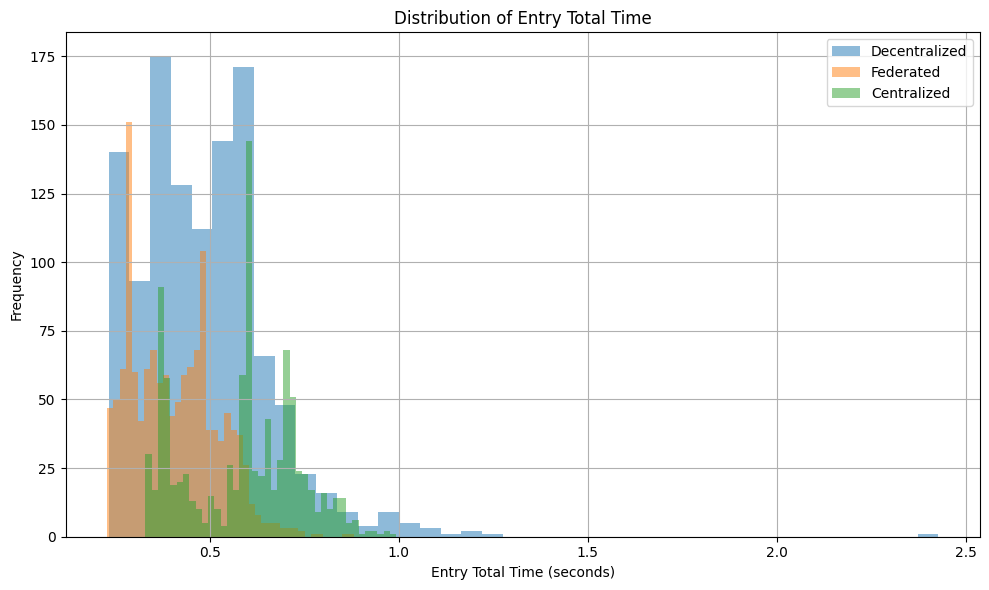

         mode     mean      std      min      max  p99/p50  p90/p50  percent > 3  percent > 4
Decentralized 0.486183 0.171535 0.231933 2.427539 2.133930 1.420825          0.0          0.0
    Federated 0.406785 0.113232 0.228113 0.880999 1.747887 1.408072          0.0          0.0
  Centralized 0.584489 0.149214 0.329098 0.992692 1.489993 1.275520          0.0          0.0


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
concurrency = 5
paths = [
    f"results_basic_decentralized_{concurrency}.csv",
    f"results_basic_federated_{concurrency}.csv",
    f"results_basic_centralized_{concurrency}.csv"
]
labels = ["Decentralized", "Federated", "Centralized"]

dataframes = [pd.read_csv(p) for p in paths]

stats_summary = []

plt.figure(figsize=(10, 6))
for df, label in zip(dataframes, labels):
    total_times = df["total_time"].dropna()
    total_times = total_times[(total_times != -1) & total_times.notna()]
    plt.hist(total_times, bins=40, alpha=0.5, label=label)

    stats_summary.append({
        "mode": label,
        "mean": total_times.mean(),
        "std": total_times.std(),
        "min": total_times.min(),
        "max": total_times.max(),
        "p99/p50": np.percentile(total_times, 99) / np.percentile(total_times, 50),
        "p90/p50": np.percentile(total_times, 90) / np.percentile(total_times, 50),
        "percent > 3": (total_times > 3).sum() / len(total_times) * 100,
        "percent > 4": (total_times > 4).sum() / len(total_times) * 100
    })

plt.title("Distribution of Entry Total Time")
plt.xlabel("Entry Total Time (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(stats_summary)

print(summary_df.to_string(index=False))

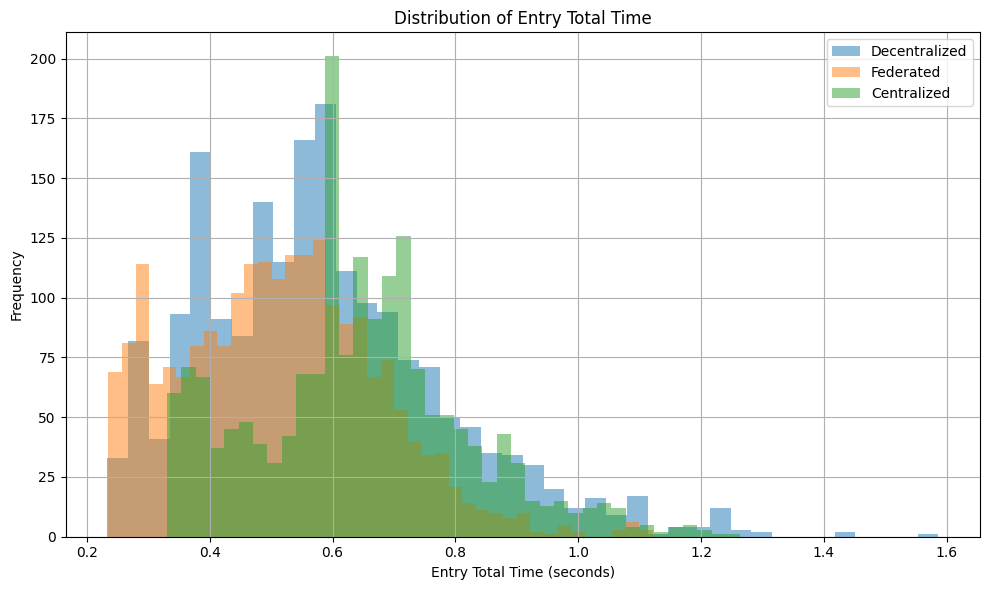

         mode     mean      std      min      max  p99/p50  p90/p50  percent > 3  percent > 4
Decentralized 0.581962 0.201208 0.232940 1.586681 2.146706 1.502338          0.0          0.0
    Federated 0.512926 0.160833 0.234797 1.121457 1.800963 1.401372          0.0          0.0
  Centralized 0.643668 0.174498 0.330292 1.264121 1.723243 1.363088          0.0          0.0


In [43]:

concurrency = 10
paths = [
    f"results_basic_decentralized_{concurrency}.csv",
    f"results_basic_federated_{concurrency}.csv",
    f"results_basic_centralized_{concurrency}.csv"
]
labels = ["Decentralized", "Federated", "Centralized"]

dataframes = [pd.read_csv(p) for p in paths]

stats_summary = []

plt.figure(figsize=(10, 6))
for df, label in zip(dataframes, labels):
    total_times = df["total_time"].dropna()
    total_times = total_times[(total_times != -1) & total_times.notna()]
    plt.hist(total_times, bins=40, alpha=0.5, label=label)

    stats_summary.append({
        "mode": label,
        "mean": total_times.mean(),
        "std": total_times.std(),
        "min": total_times.min(),
        "max": total_times.max(),
        "p99/p50": np.percentile(total_times, 99) / np.percentile(total_times, 50),
        "p90/p50": np.percentile(total_times, 90) / np.percentile(total_times, 50),
        "percent > 3": (total_times > 3).sum() / len(total_times) * 100,
        "percent > 4": (total_times > 4).sum() / len(total_times) * 100
    })

plt.title("Distribution of Entry Total Time")
plt.xlabel("Entry Total Time (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(stats_summary)

print(summary_df.to_string(index=False))

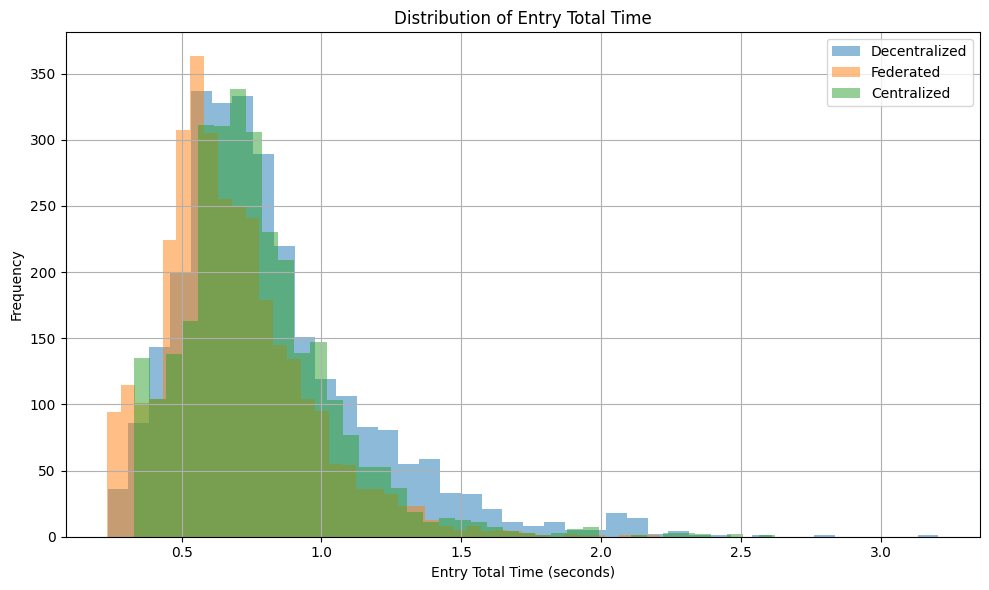

         mode     mean      std      min      max  p99/p50  p90/p50  percent > 3  percent > 4
Decentralized 0.818887 0.350632 0.235740 3.206522 2.803335 1.728344     0.035791          0.0
    Federated 0.685127 0.259956 0.234116 2.212593 2.327801 1.586413     0.000000          0.0
  Centralized 0.773486 0.275410 0.330752 2.622709 2.357314 1.508953     0.000000          0.0


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
concurrency = 20
paths = [
    f"results_basic_decentralized_{concurrency}.csv",
    f"results_basic_federated_{concurrency}.csv",
    f"results_basic_centralized_{concurrency}.csv"
]
labels = ["Decentralized", "Federated", "Centralized"]

dataframes = [pd.read_csv(p) for p in paths]

stats_summary = []

plt.figure(figsize=(10, 6))
for df, label in zip(dataframes, labels):
    total_times = df["total_time"].dropna()
    total_times = total_times[(total_times != -1) & total_times.notna()]
    plt.hist(total_times, bins=40, alpha=0.5, label=label)
    
    stats_summary.append({
        "mode": label,
        "mean": total_times.mean(),
        "std": total_times.std(),
        "min": total_times.min(),
        "max": total_times.max(),
        "p99/p50": np.percentile(total_times, 99) / np.percentile(total_times, 50),
        "p90/p50": np.percentile(total_times, 90) / np.percentile(total_times, 50),
        "percent > 3": (total_times > 3).sum() / len(total_times) * 100,
        "percent > 4": (total_times > 4).sum() / len(total_times) * 100
    })

plt.title("Distribution of Entry Total Time")
plt.xlabel("Entry Total Time (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(stats_summary)

print(summary_df.to_string(index=False))


In [64]:
import pandas as pd
import matplotlib.pyplot as plt

concurrency = 40
paths = [
    f"results_basic_decentralized_{concurrency}.csv",
    f"results_basic_federated_{concurrency}.csv",
    f"results_basic_centralized_{concurrency}.csv"
]
labels = ["Decentralized", "Federated", "Centralized"]

dataframes = [pd.read_csv(p) for p in paths]

stats_summary = []

plt.figure(figsize=(10, 6))
for df, label in zip(dataframes, labels):
    total_times = df["total_time"].dropna()
    total_times = total_times[(total_times != -1) & total_times.notna()]
    plt.hist(total_times, bins=40, alpha=0.5, label=label)

    stats_summary.append({
        "mode": label,
        "mean": total_times.mean(),
        "std": total_times.std(),
        "min": total_times.min(),
        "max": total_times.max(),
        "p99/p50": np.percentile(total_times, 99) / np.percentile(total_times, 50),
        "p95/p50": np.percentile(total_times, 95) / np.percentile(total_times, 50),
        "p90/p50": np.percentile(total_times, 90) / np.percentile(total_times, 50),
        "percent > 3": (total_times > 3).sum() / len(total_times) * 100,
        "percent > 4": (total_times > 4).sum() / len(total_times) * 100
    })

plt.title("Distribution of Entry Total Time")
plt.xlabel("Entry Total Time (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(stats_summary)

print(summary_df.to_string(index=False))

FileNotFoundError: [Errno 2] No such file or directory: 'results_basic_decentralized_40.csv'

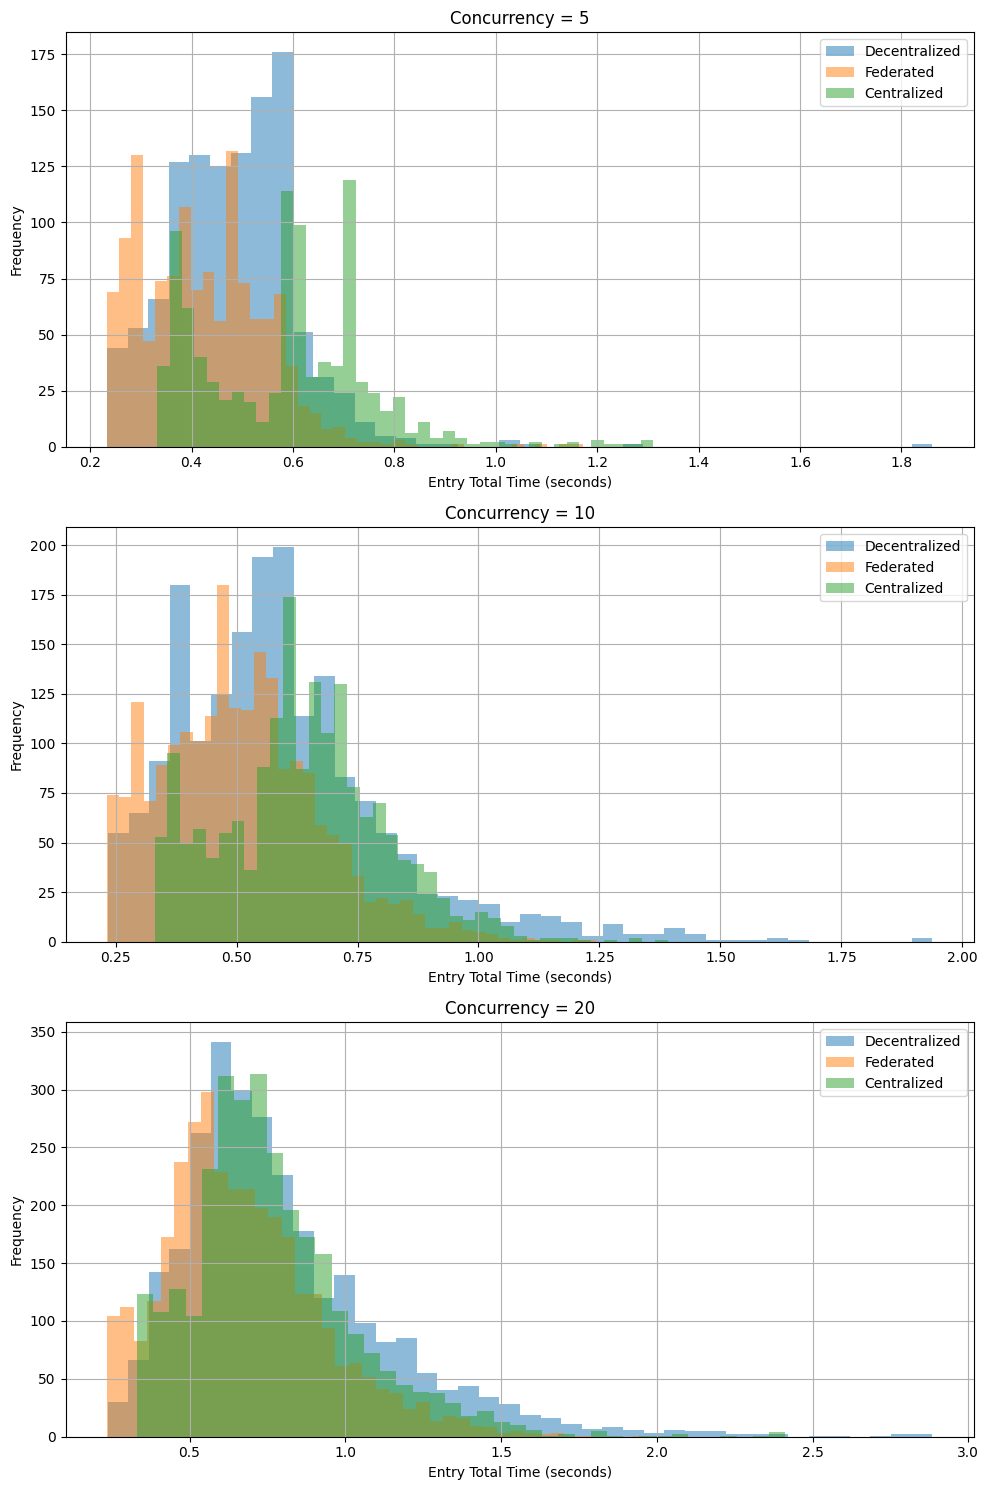

 concurrency          mode     mean      std      min      max      p50  p99/p50  p95/p50  p90/p50  percent > 3  percent > 4
           5 Decentralized 0.483667 0.127901 0.233105 1.860913 0.486969 1.649361 1.382399 1.252753     0.000000          0.0
           5     Federated 0.423172 0.122784 0.234008 1.172069 0.410273 1.779907 1.495398 1.409054     0.000000          0.0
           5   Centralized 0.590164 0.166178 0.332098 1.310876 0.600850 1.901975 1.386966 1.273268     0.000000          0.0
          10 Decentralized 0.593440 0.225568 0.234346 1.938110 0.566299 2.442115 1.824649 1.520480     0.000000          0.0
          10     Federated 0.507869 0.163760 0.232068 1.243126 0.494043 1.974436 1.626095 1.452122     0.000000          0.0
          10   Centralized 0.641130 0.168467 0.330498 1.391470 0.639467 1.667434 1.447947 1.337498     0.000000          0.0
          20 Decentralized 0.804790 0.345209 0.236763 2.884699 0.723382 2.802065 2.026887 1.732456     1.104382          0.0


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
concurrencies = [5, 10, 20]
labels = ["Decentralized", "Federated", "Centralized"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"] 
function = "data_local"
all_stats = []

fig, axes = plt.subplots(len(concurrencies), 1, figsize=(10, 5 * len(concurrencies)))

for i, concurrency in enumerate(concurrencies):
    stats_summary = []
    ax = axes[i]

    for j, label in enumerate(labels):
        path = Path(function) / f"results_{function}_{label.lower()}_{concurrency}.csv"
        df = pd.read_csv(path)
        total_times = df["total_time"].dropna()
        total_times = total_times[(total_times != -1) & total_times.notna()]
        ax.hist(total_times, bins=40, alpha=0.5, label=label, color=colors[j])

        stats_summary.append({
            "concurrency": concurrency,
            "mode": label,
            "mean": total_times.mean(),
            "std": total_times.std(),
            "min": total_times.min(),
            "max": total_times.max(),
            "p50": np.percentile(total_times, 50),
            "p99/p50": np.percentile(total_times, 99) / np.percentile(total_times, 50),
            "p95/p50": np.percentile(total_times, 95) / np.percentile(total_times, 50),
            "p90/p50": np.percentile(total_times, 90) / np.percentile(total_times, 50),
            "percent > 3": (total_times > 2).sum() / len(total_times) * 100,
            "percent > 4": (total_times > 3).sum() / len(total_times) * 100
        })

    ax.set_title(f"Concurrency = {concurrency}")
    ax.set_xlabel("Entry Total Time (seconds)")
    ax.set_ylabel("Frequency")
    ax.grid(True)
    ax.legend()
    
    all_stats.extend(stats_summary)

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(all_stats)
print(summary_df.to_string(index=False))


 concurrency          mode     mean      std      min      max      p50  p99/p50  p95/p50  p90/p50  percent > 3  percent > 4
           5 Decentralized 0.483667 0.127901 0.233105 1.860913 0.486969 1.649361 1.382399 1.252753     0.000000          0.0
           5     Federated 0.423172 0.122784 0.234008 1.172069 0.410273 1.779907 1.495398 1.409054     0.000000          0.0
           5   Centralized 0.590164 0.166178 0.332098 1.310876 0.600850 1.901975 1.386966 1.273268     0.000000          0.0
          10 Decentralized 0.593440 0.225568 0.234346 1.938110 0.566299 2.442115 1.824649 1.520480     0.000000          0.0
          10     Federated 0.507869 0.163760 0.232068 1.243126 0.494043 1.974436 1.626095 1.452122     0.000000          0.0
          10   Centralized 0.641130 0.168467 0.330498 1.391470 0.639467 1.667434 1.447947 1.337498     0.000000          0.0
          20 Decentralized 0.804790 0.345209 0.236763 2.884699 0.723382 2.802065 2.026887 1.732456     1.104382          0.0


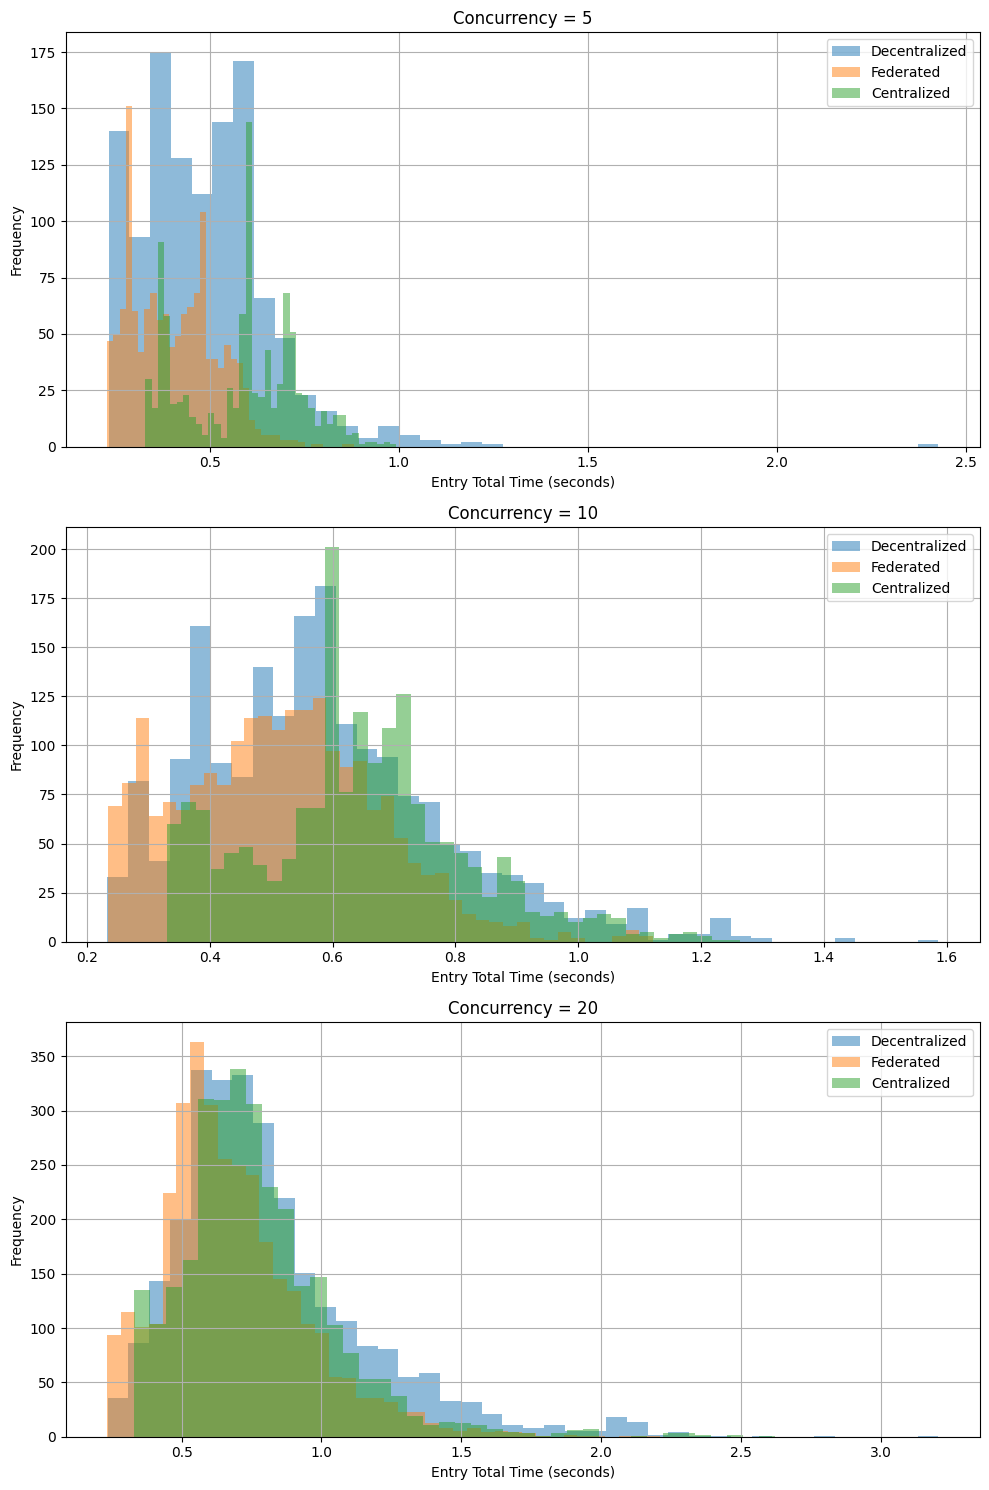

 concurrency          mode     mean      std      min      max      p50  p99/p50  p95/p50  p90/p50  percent > 3  percent > 4
           5 Decentralized 0.486183 0.171535 0.231933 2.427539 0.477572 2.133930 1.581121 1.420825     0.086881     0.000000
           5     Federated 0.406785 0.113232 0.228113 0.880999 0.397810 1.747887 1.489279 1.408072     0.000000     0.000000
           5   Centralized 0.584489 0.149214 0.329098 0.992692 0.598919 1.489993 1.379637 1.275520     0.000000     0.000000
          10 Decentralized 0.581962 0.201208 0.232940 1.586681 0.563817 2.146706 1.690895 1.502338     0.000000     0.000000
          10     Federated 0.512926 0.160833 0.234797 1.121457 0.511301 1.800963 1.523948 1.401372     0.000000     0.000000
          10   Centralized 0.643668 0.174498 0.330292 1.264121 0.642155 1.723243 1.493829 1.363088     0.000000     0.000000
          20 Decentralized 0.818887 0.350632 0.235740 3.206522 0.742401 2.803335 2.011084 1.728344     1.610594     0.035791


In [66]:
print(summary_df.to_string(index=False))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

concurrencies = [5, 10, 20]
labels = ["Decentralized", "Federated", "Centralized"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

function = "basic"
all_stats = []

fig, axes = plt.subplots(len(concurrencies), 1, figsize=(10, 5 * len(concurrencies)))

for i, concurrency in enumerate(concurrencies):
    stats_summary = []
    ax = axes[i]

    for j, label in enumerate(labels):
        path = f"{function}/results_{function}_{label.lower()}_{concurrency}.csv"
        df = pd.read_csv(path)
        total_times = df["total_time"].dropna()
        total_times = total_times[(total_times != -1) & total_times.notna()]
        ax.hist(total_times, bins=40, alpha=0.5, label=label, color=colors[j])

        stats_summary.append({
            "concurrency": concurrency,
            "mode": label,
            "mean": total_times.mean(),
            "std": total_times.std(),
            "min": total_times.min(),
            "max": total_times.max(),
            "p50": np.percentile(total_times, 50),
            "p99/p50": np.percentile(total_times, 99) / np.percentile(total_times, 50),
            "p95/p50": np.percentile(total_times, 95) / np.percentile(total_times, 50),
            "p90/p50": np.percentile(total_times, 90) / np.percentile(total_times, 50),
            "percent > 3": (total_times > 2).sum() / len(total_times) * 100,
            "percent > 4": (total_times > 3).sum() / len(total_times) * 100
        })

    ax.set_title(f"Concurrency = {concurrency}")
    ax.set_xlabel("Entry Total Time (seconds)")
    ax.set_ylabel("Frequency")
    ax.grid(True)
    ax.legend()

    all_stats.extend(stats_summary)

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(all_stats)
print(summary_df.to_string(index=False))